# E-Commerce Customer Churn Prediction & Analytics

### Project Overview
This project presents an end-to-end machine learning pipeline to analyze and predict customer churn in an e-commerce platform. By identifying key drivers behind customer attrition—ranging from tenure and complaint status to financial incentives—we build predictive intelligence to enhance customer retention strategies.


## importing relevent libraries

In [35]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn import metrics
import itertools


## importing the Data 

In [36]:
raw_data = pd.read_excel("E Commerce Dataset.xlsx" , sheet_name= "E Comm")
raw_data.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


## Dataset Columns

<div dir="rtl">

---

- **`CustomerID`**: شناسه یکتا برای هر مشتری.
- **`Churn`**: متغیر هدف (Target Variable)؛ مشخص‌کننده وضعیت ماندگاری یا خروج مشتری (`1` = ریزش کرده، `0` = وفادار/مانده).


- **`Gender`**: جنسیت مشتری (`Male` یا `Female`).
- **`MaritalStatus`**: وضعیت تأهل مشتری (`Single`, `Married`, `Divorced`).
- **`CityTier`**: سطح و رتبه توسعه‌یافتگی شهر محل سکونت مشتری با مقادیر ترتیبی `1` (کلان‌شهرها)، `2` و `3`.
- **`NumberOfAddress`**: تعداد کل آدرس‌های پستی ثبت‌شده در حساب کاربری مشتری برای ارسال سفارش‌ها.

---

- **`Tenure`**: مدت‌زمان عضویت کاربر در سامانه بر حسب ماه (شاخص سابقه وفاداری).
- **`PreferredLoginDevice`**: نوع دستگاه ترجیحی کاربر هنگام ورود به پلتفرم (`Mobile Phone`, `Computer`).
- **`HourSpendOnApp`**: میانگین مدت‌زمان (ساعت) سپری‌شده توسط کاربر در اپلیکیشن یا وب‌سایت در طول شبانه‌روز.
- **`NumberOfDeviceRegistered`**: تعداد کل دستگاه‌های فعال و متصل به حساب کاربری مشتری.

---

- **`WarehouseToHome`**: فاصله تخمینی از نزدیک‌ترین انبار ارسال کالا تا آدرس منزل مشتری (بر حسب کیلومتر).
- **`PreferredPaymentMode`**: روش پرداخت ترجیحی مشتری (`Debit Card`, `Credit Card`, `E wallet`, `UPI`, `COD`).
- **`PreferedOrderCat`**: دسته‌بندی کالاهایی که بیشترین حجم خرید مشتری را در ماه گذشته تشکیل داده‌اند (`Laptop & Accessory`, `Mobile`, `Fashion`, `Grocery`, `Others`).
- **`SatisfactionScore`**: امتیاز رضایت اعلام‌شده توسط کاربر از خدمات پشتیبانی و پلتفرم (مقیاس ۱ تا ۵).
- **`Complain`**: وضعیت ثبت شکایت در ماه گذشته (`1` = ثبت شکایت، `0` = بدون شکایت).
- **`OrderAmountHikeFromlastYear`**: درصد رشد ارزش ریالی خریدهای کاربر نسبت به سال پیش.
- **`CouponUsed`**: تعداد کل کوپن‌های تخفیف استفاده‌شده در ماه گذشته.
- **`OrderCount`**: تعداد سفارش‌های نهایی‌شده کاربر در ماه گذشته.
- **`DaySinceLastOrder`**: تعداد روزهای سپری‌شده از آخرین خرید تا زمان استخراج داده.
- **`CashbackAmount`**: میانگین مبلغ بازگشت وجه (Cashback) تعلق‌گرفته به خریدهای مشتری در ماه اخیر.
</div>

## Initial Data Inspection & Identifier Removal
Examine descriptive statistics, dataset dimensions, and data types across all features, followed by dropping the non-informative `CustomerID` column.

In [37]:
raw_data.describe(include="all")

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5366.000000,5630,5630.000000,5379.000000,5630,5630,5375.000000,5630.000000,5630,5630.000000,5630,5630.000000,5630.000000,5365.000000,5374.000000,5372.000000,5323.000000,5630.000000
unique,NaN,NaN,NaN,3,NaN,NaN,7,2,NaN,NaN,6,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,Mobile Phone,NaN,NaN,Debit Card,Male,NaN,NaN,Laptop & Accessory,NaN,Married,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,2765,NaN,NaN,2314,3384,NaN,NaN,2050,NaN,2986,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,52815.500000,0.168384,10.189899,NaN,1.654707,15.639896,NaN,NaN,2.931535,3.688988,NaN,3.066785,NaN,4.214032,0.284902,15.707922,1.751023,3.008004,4.543491,177.223030
std,1625.385339,0.374240,8.557241,NaN,0.915389,8.531475,NaN,NaN,0.721926,1.023999,NaN,1.380194,NaN,2.583586,0.451408,3.675485,1.894621,2.939680,3.654433,49.207036
min,50001.000000,0.000000,0.000000,NaN,1.000000,5.000000,NaN,NaN,0.000000,1.000000,NaN,1.000000,NaN,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,51408.250000,0.000000,2.000000,NaN,1.000000,9.000000,NaN,NaN,2.000000,3.000000,NaN,2.000000,NaN,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,145.770000
50%,52815.500000,0.000000,9.000000,NaN,1.000000,14.000000,NaN,NaN,3.000000,4.000000,NaN,3.000000,NaN,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.280000
75%,54222.750000,0.000000,16.000000,NaN,3.000000,20.000000,NaN,NaN,3.000000,4.000000,NaN,4.000000,NaN,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.392500


In [38]:
print(raw_data.shape)
print(raw_data.dtypes)

(5630, 20)
CustomerID                       int64
Churn                            int64
Tenure                         float64
PreferredLoginDevice            object
CityTier                         int64
WarehouseToHome                float64
PreferredPaymentMode            object
Gender                          object
HourSpendOnApp                 float64
NumberOfDeviceRegistered         int64
PreferedOrderCat                object
SatisfactionScore                int64
MaritalStatus                   object
NumberOfAddress                  int64
Complain                         int64
OrderAmountHikeFromlastYear    float64
CouponUsed                     float64
OrderCount                     float64
DaySinceLastOrder              float64
CashbackAmount                 float64
dtype: object


In [39]:
raw_data.drop(['CustomerID'],axis=1, inplace=True)

In [40]:
raw_data.nunique()

Churn                             2
Tenure                           36
PreferredLoginDevice              3
CityTier                          3
WarehouseToHome                  34
PreferredPaymentMode              7
Gender                            2
HourSpendOnApp                    6
NumberOfDeviceRegistered          6
PreferedOrderCat                  6
SatisfactionScore                 5
MaritalStatus                     3
NumberOfAddress                  15
Complain                          2
OrderAmountHikeFromlastYear      16
CouponUsed                       17
OrderCount                       16
DaySinceLastOrder                22
CashbackAmount                 2586
dtype: int64

## Missing Value Imputation
Check missing value counts across features and impute missing entries using the median of each respective column.

In [41]:
raw_data.isnull().sum()

Churn                            0
Tenure                         264
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
dtype: int64

In [42]:
for i in raw_data.columns:
    if raw_data[i].isnull().sum() > 0:
        raw_data[i].fillna(raw_data[i].median(),inplace=True)

raw_data.isnull().sum()

Churn                          0
Tenure                         0
PreferredLoginDevice           0
CityTier                       0
WarehouseToHome                0
PreferredPaymentMode           0
Gender                         0
HourSpendOnApp                 0
NumberOfDeviceRegistered       0
PreferedOrderCat               0
SatisfactionScore              0
MaritalStatus                  0
NumberOfAddress                0
Complain                       0
OrderAmountHikeFromlastYear    0
CouponUsed                     0
OrderCount                     0
DaySinceLastOrder              0
CashbackAmount                 0
dtype: int64

## Cleaning Categorical Features
Check category counts and merge duplicate labels (like merging Mobile into Mobile Phone, and CC into Credit Card).

In [43]:
for i in raw_data.columns:
    if raw_data[i].dtypes == 'object':
        print(i)
        print()
        print('the values are:') 
        print(raw_data[i].value_counts())
        print()
        print()


PreferredLoginDevice

the values are:
PreferredLoginDevice
Mobile Phone    2765
Computer        1634
Phone           1231
Name: count, dtype: int64


PreferredPaymentMode

the values are:
PreferredPaymentMode
Debit Card          2314
Credit Card         1501
E wallet             614
UPI                  414
COD                  365
CC                   273
Cash on Delivery     149
Name: count, dtype: int64


Gender

the values are:
Gender
Male      3384
Female    2246
Name: count, dtype: int64


PreferedOrderCat

the values are:
PreferedOrderCat
Laptop & Accessory    2050
Mobile Phone          1271
Fashion                826
Mobile                 809
Grocery                410
Others                 264
Name: count, dtype: int64


MaritalStatus

the values are:
MaritalStatus
Married     2986
Single      1796
Divorced     848
Name: count, dtype: int64




In [44]:
#As mobile phone and Mobile are both same so we have merged them
raw_data.loc[raw_data['PreferedOrderCat'] == 'Mobile', 'PreferedOrderCat' ] = 'Mobile Phone'
print(raw_data["PreferedOrderCat"].value_counts(),'\n')


# merging the payment methods
raw_data["PreferredPaymentMode"] = raw_data["PreferredPaymentMode"].replace(
    {"CC": "Credit Card", "COD": "Cash on Delivery"}
)
print(raw_data["PreferredPaymentMode"].value_counts())


PreferedOrderCat
Mobile Phone          2080
Laptop & Accessory    2050
Fashion                826
Grocery                410
Others                 264
Name: count, dtype: int64 

PreferredPaymentMode
Debit Card          2314
Credit Card         1774
E wallet             614
Cash on Delivery     514
UPI                  414
Name: count, dtype: int64


## Outlier Detection & Capping (IQR Method)
Visualize continuous features using boxplots and cap extreme outliers using the Interquartile Range (IQR) method.

In [45]:
# variables to handle for outliers
continuous_cols = [
    "Tenure",
    "WarehouseToHome",
    "HourSpendOnApp",
    "NumberOfAddress",
    "OrderAmountHikeFromlastYear",
    "CouponUsed",
    "OrderCount",
    "DaySinceLastOrder",
    "CashbackAmount",
]

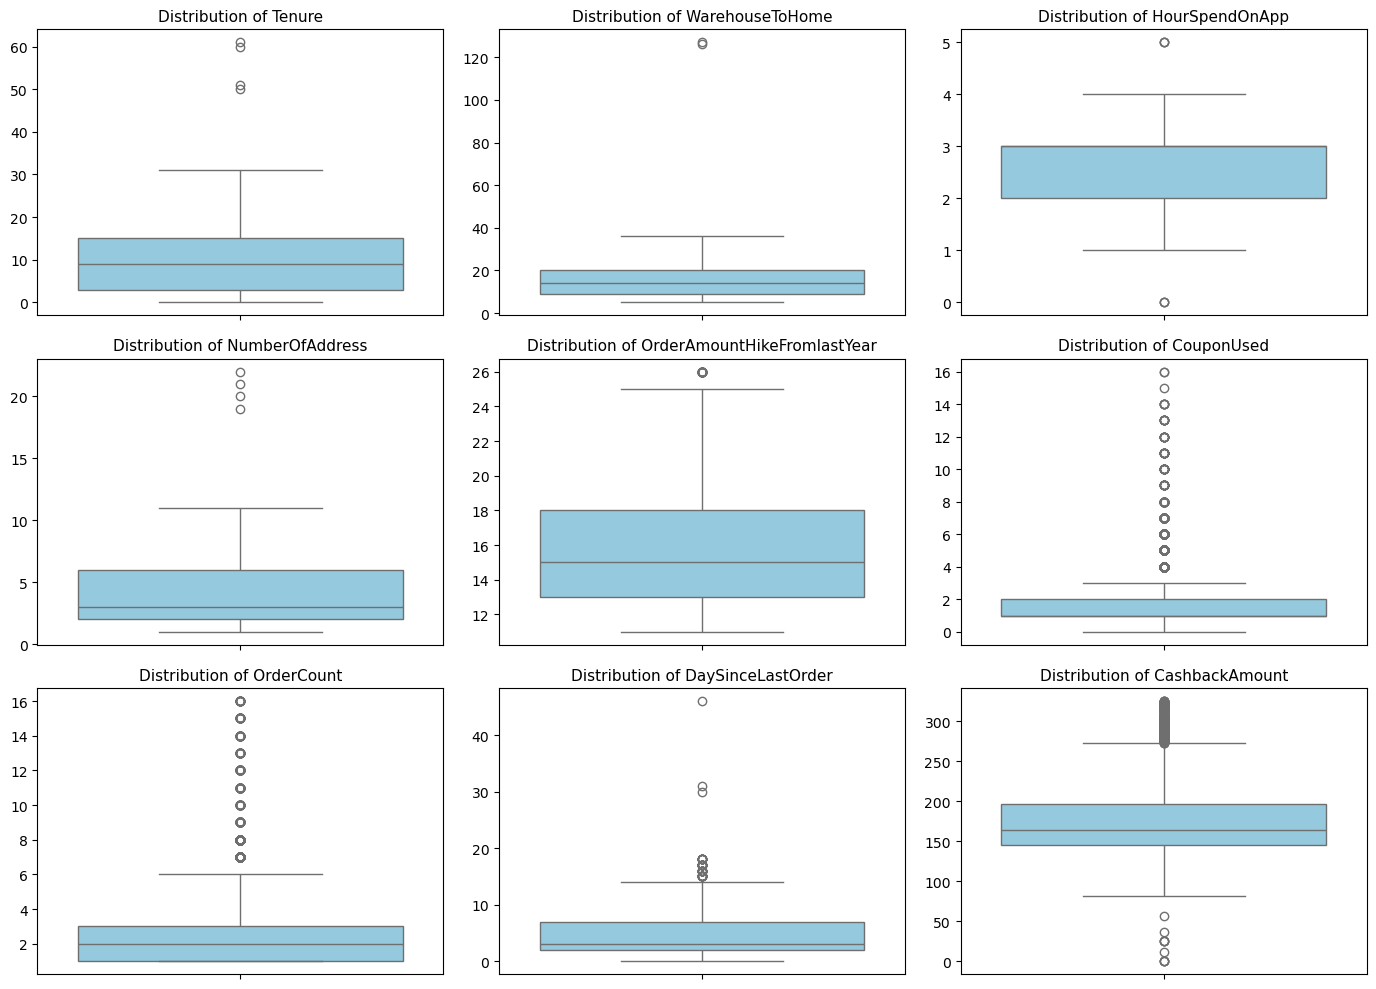

In [46]:
# plotting of box plots only for continuous variables
plt.figure(figsize=(14, 10))
for i, col in enumerate(continuous_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=raw_data[col], color="skyblue")
    plt.title(f"Distribution of {col}", fontsize=11)
    plt.ylabel("")

plt.tight_layout()
plt.show()

In [47]:
def remove_outlier(col):
    sorted(col)
    Q1,Q3=np.percentile(col,[25,75])
    IQR=Q3-Q1
    lr= Q1-(1.5 * IQR)
    ur= Q3+(1.5 * IQR)
    return lr, ur


In [48]:
# handling outliers for our variables
data_cleaned = raw_data.copy()

for col in continuous_cols:
    lr, ur = remove_outlier(data_cleaned[col])
    data_cleaned[col] = np.where(data_cleaned[col] > ur, ur, data_cleaned[col])
    data_cleaned[col] = np.where(data_cleaned[col] < lr, lr, data_cleaned[col])

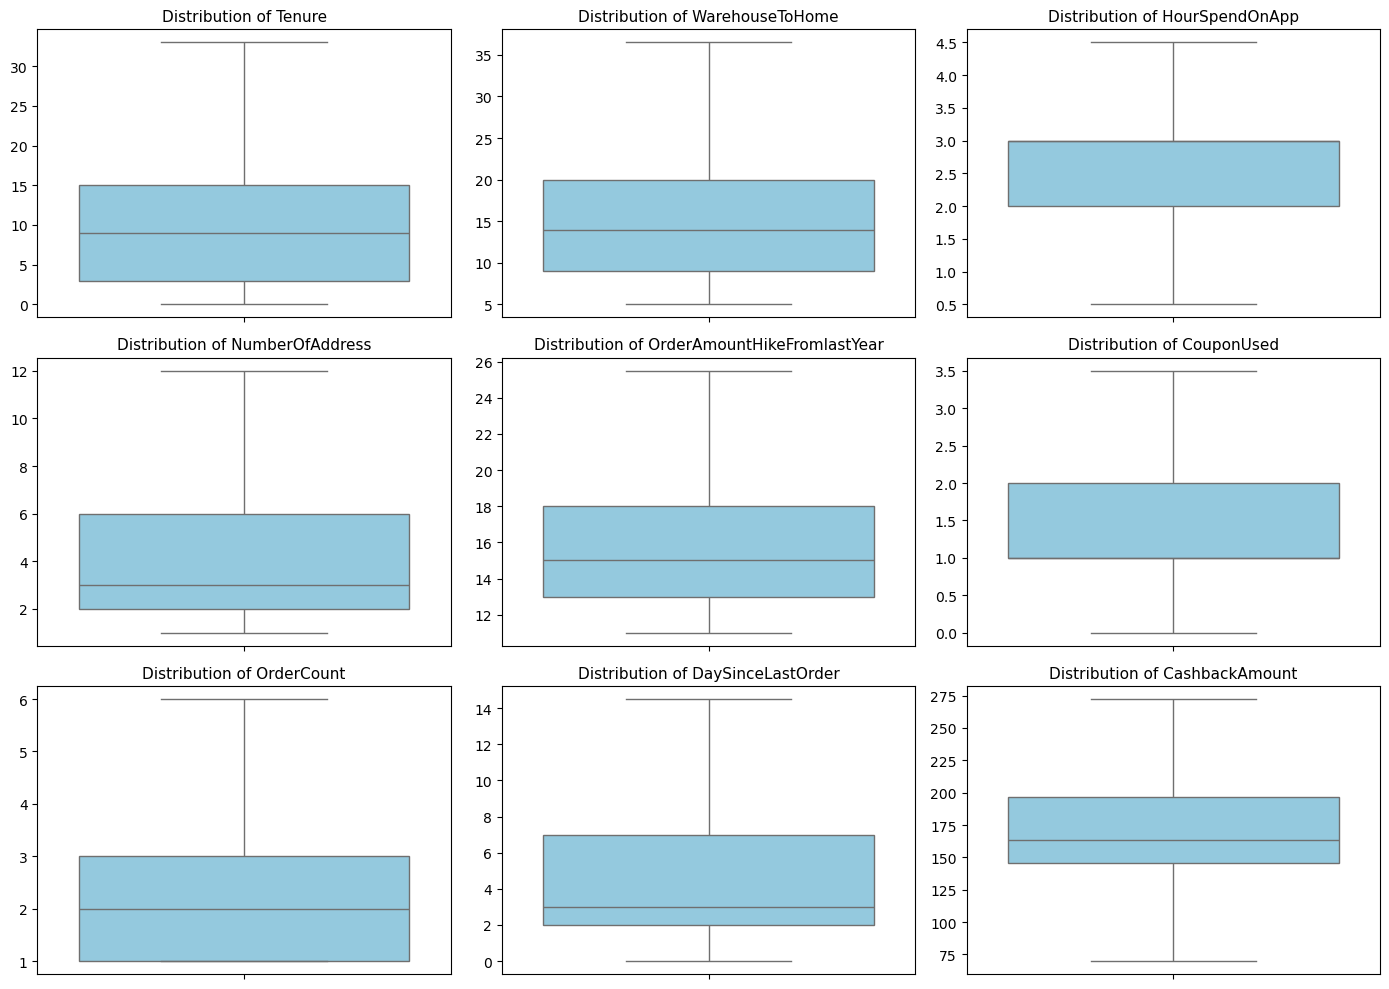

In [49]:
# plotting of box plots only for continuous variables
plt.figure(figsize=(14, 10))
for i, col in enumerate(continuous_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=data_cleaned[col], color="skyblue")
    plt.title(f"Distribution of {col}", fontsize=11)
    plt.ylabel("")

plt.tight_layout()
plt.show()

## Feature Engineering: Average Cashback per Order
Create a new feature representing the average cashback earned per order to measure customer financial incentive.

In [50]:
#adding new feature to our dataset(avg cash back per order)
data_cleaned['avg_cashbk_per_order'] = data_cleaned['CashbackAmount'] / data_cleaned['OrderCount']

## Baseline Churn Ratio
Calculate the percentage ratio of churned customers relative to retained customers.
> **Analytical Note:**  
> - **Churn-to-Retention Ratio:** The metric below evaluates the ratio of lost customers relative to retained customers (`948 / 4,682 ≈ 20.25%`), indicating that for every 100 retained customers, approximately 20 customers leave the platform.
> - **Overall Churn Rate:** Relative to the total customer base (`5,630`), the true churn rate stands at **16.84%** versus **83.16%** retention. This confirmed class imbalance highlights why standard accuracy alone will be misleading, making precision, recall, and ROC-AUC our primary evaluation metrics during modeling.

In [51]:
# Percentage of customer churn
Churn_perc = round((data_cleaned['Churn'][data_cleaned['Churn']==1].count()*100/data_cleaned['Churn'][data_cleaned['Churn']==0].count()),2)
Churn_perc

np.float64(20.25)

## EDA
<div dir="rtl">

### ۱. ارزیابی توزیع کلاس هدف و نسبت ریزش (Target Imbalance Analysis)
- **وضعیت آماری:** از میان ۵,۶۳۰ مشتری پلتفرم، ۸۳.۱۶٪ (۴,۶۸۲ نفر) وفادار مانده‌اند و ۱۶.۸۴٪ (۹۴۸ نفر) ریزش کرده‌اند.
- **دیدگاه کسب‌وکار:** با وجود پایبندی اکثریت کاربران، از دست رفتن نزدیک به ۱۷٪ مشتریان (معادل نسبت تقریبی ۱ به ۵) زنگ خطری جدی برای درآمد مستمر و ارزش دوره عمر مشتریان  پلتفرم محسوب می‌شود.

</div>

تعداد مشتریان مانده (0): 4682 (83.16%)
تعداد مشتریان ریزش‌کرده (1): 948 (16.84%)


/tmp/ipykernel_7772/827306638.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="Churn", data=data_cleaned, palette="Set2")


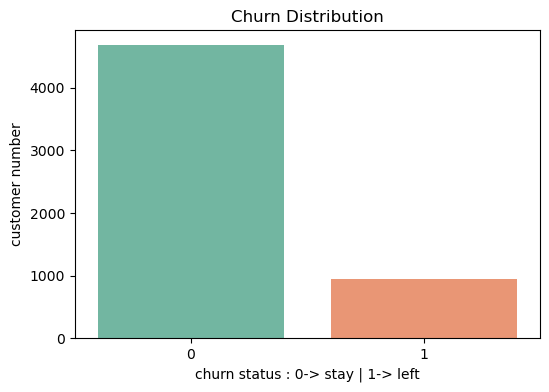

In [52]:
# Churn rate and count versus retention
churn_counts = data_cleaned["Churn"].value_counts()
churn_rates = data_cleaned["Churn"].value_counts(normalize=True) * 100

print(f"تعداد مشتریان مانده (0): {churn_counts[0]} ({churn_rates[0]:.2f}%)")
print(f"تعداد مشتریان ریزش‌کرده (1): {churn_counts[1]} ({churn_rates[1]:.2f}%)")

# Plotting the target distribution bar chart
plt.figure(figsize=(6, 4))
ax = sns.countplot(x="Churn", data=data_cleaned, palette="Set2")
plt.title("Churn Distribution", fontsize=12)
plt.xlabel("churn status : 0-> stay | 1-> left")
plt.ylabel("customer number")


plt.show()

<div dir="rtl">

### تحلیل توزیع آماری متغیرهای پیوسته کلیدی (Continuous Features Distribution)

در این بخش، شکل توزیع آماری و رفتار طبیعی چهار ویژگی پیوسته و حیاتی پلتفرم پیش از ورود به فاز یادگیری ماشین بررسی می‌شود:

- **سابقه عضویت و وفاداری کاربر (`Tenure`):** توزیع داده‌ها چولگی مثبت واضحی دارد و بیشترین تراکم مشتریان در ماه‌های ابتدایی (زیر ۱۰ ماه) قرار گرفته است. این ساختار نشان می‌دهد ورود کاربران جدید با شتاب بالا انجام می‌شود، اما فرآیند تبدیل آن‌ها به مشتریان پایدار و کهنه‌کار با مانع و خروج مواجه است.
- **توزیع مشوق مالی بازگشت وجه (`CashbackAmount`):** این متغیر توزیعی متقارن و نزدیک به نرمال با میانگین ۱۷۷ واحد و تمرکز در بازه ۱۴۵ تا ۱۹۶ دارد. این یکدستی نشان می‌دهد سیاست‌های اعطای اعتبار و کش‌بک در پلتفرم به شکل سیستماتیک توزیع شده و انگیزه خرید مستمر را حفظ می‌کند.
- **فاصله مکانی از انبار تا منزل (`WarehouseToHome`):** بیشتر مشتریان در شعاع ۱۵ کیلومتری انبارها قرار دارند. با این حال، ثبت فاصله‌های بالای 30 کیلومتر لزوم بهینه‌سازی زنجیره تأمین و نظارت بر زمان تحویل کالا برای کاهش اصطکاک را یادآوری می‌کند.
- **فاصله زمانی از آخرین سفارش (`DaySinceLastOrder`):** اکثریت کاربران در بازه کمتر از ۷ روز گذشته اقدام به ثبت سفارش کرده‌اند که نشانه گردش خریدهای جاری در سایت است.

</div>

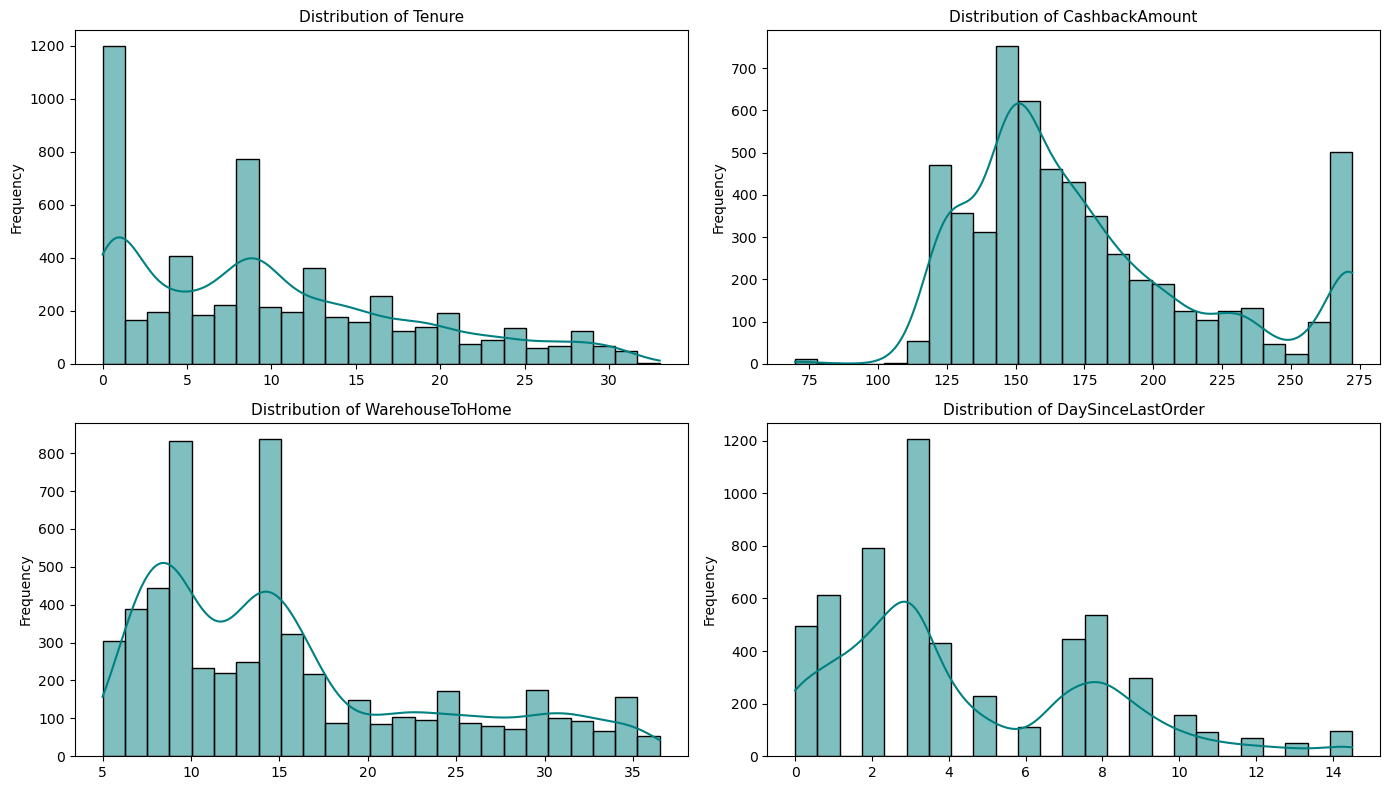

In [53]:
key_num_cols = ["Tenure", "CashbackAmount", "WarehouseToHome", "DaySinceLastOrder"]

plt.figure(figsize=(14, 8))
for i, col in enumerate(key_num_cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(data_cleaned[col], kde=True, color="teal", bins=25)
    plt.title(f"Distribution of {col}", fontsize=11)
    plt.xlabel("")
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

<div dir="rtl">

###  تحلیل ویژگی‌های دموگرافیک (جمعیت شناسی) ، ترجیحات خرید و تعاملات (Categorical Features Analysis)

در این بخش، فراوانی دسته‌بندی‌های اجتماعی، کانال‌های پرداخت و سیگنال‌های تجربه کاربری مورد ارزیابی قرار می‌گیرد:

- **ساختار اجتماعی و وضعیت تأهل (`MaritalStatus`):** کاربران متأهل با سهم ۵۳٪ بخش اصلی جامعه مشتریان را تشکیل می‌دهند. این گروه عموماً الگوی خرید باثبات‌تر و مبتنی بر نیازهای خانواده ثبت می‌کنند.
- **کانال‌های پرداخت پرکاربرد (`PreferredPaymentMode`):** کارت‌های بانکی (`Debit Card` و `Credit Card`) بیشترین سهم تراکنش‌ها را در دست دارند، در حالی که روش‌های پرداخت در محل (`Cash on Delivery`) و کیف پول دیجیتال سهم کمتری به خود اختصاص داده‌اند.
- **سبد محصولات پرتقاضا (`PreferedOrderCat`):** گروه کالایی «لپ‌تاپ و لوازم جانبی» با بیش از ۲,۰۰۰ مشتری در صدر تقاضا قرار دارد و پس از آن کالاهای دیجیتال و موبایل بیشترین حجم سفارش را دارند.
- **سیگنال شکایت و پشتیبانی (`Complain`):** ثبت تجربه شکایت توسط نزدیک به ۲۸.۵٪ از مشتریان در ماه اخیر، یک زنگ خطر جدی در کیفیت خدمات پشتیبانی است که بررسی ارتباط مستقیم آن با ترک پلتفرم در ادامه ضروری است.

</div>

/tmp/ipykernel_7772/1675610646.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_7772/1675610646.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_7772/1675610646.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_7772/1675610646.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_7772/1675610646.py:13: FutureWarn

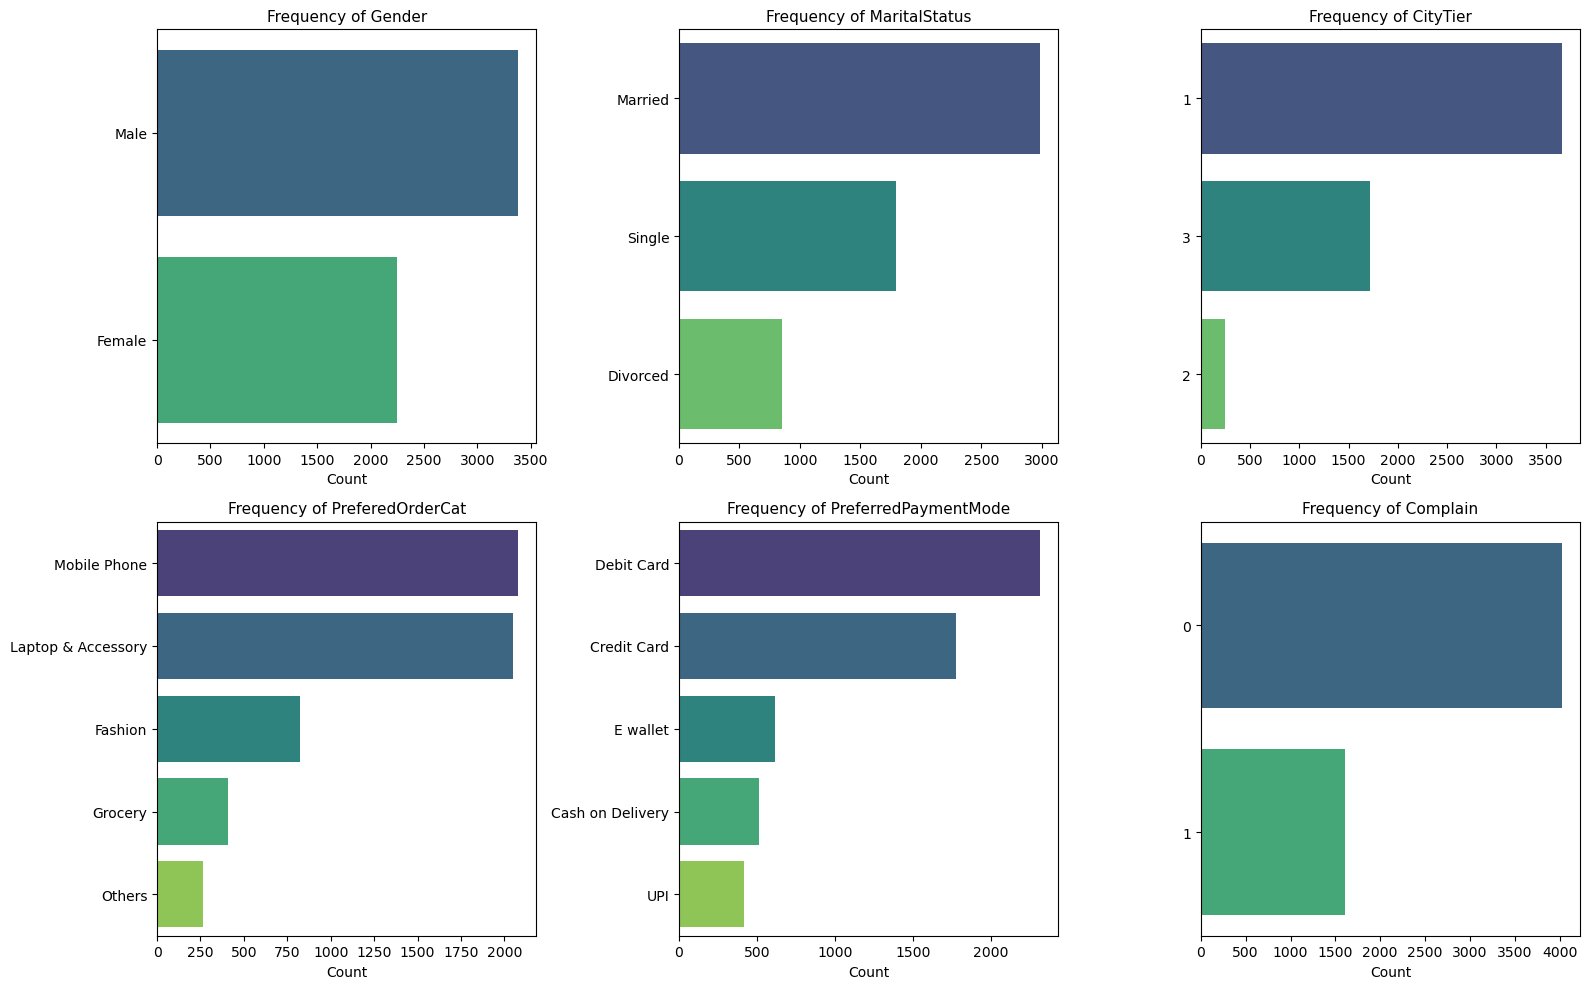

In [54]:
cat_cols = [
    "Gender",
    "MaritalStatus",
    "CityTier",
    "PreferedOrderCat",
    "PreferredPaymentMode",
    "Complain",
]

plt.figure(figsize=(16, 10))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(2, 3, i)
    sns.countplot(
        y=col,
        data=data_cleaned,
        palette="viridis",
        order=data_cleaned[col].value_counts().index,
    )
    plt.title(f"Frequency of {col}", fontsize=11)
    plt.xlabel("Count")
    plt.ylabel("")

plt.tight_layout()
plt.show()

<div dir="rtl">

### پایش رفتار درون‌برنامه‌ای، تراکنش‌های خرد و حساب کاربری (App Engagement & Transactional Patterns)

تحلیل این ۸ ویژگی تکمیلی، الگوهای رفتاری کاربران در محیط اپلیکیشن و تاریخچه تراکنش‌های آن‌ها را آشکار می‌سازد:

- **میزان درگیری با اپلیکیشن (`HourSpendOnApp`):** بیش از ۸۰٪ مشتریان روزانه به‌طور میانگین **۲ تا ۳ ساعت** در محیط پلتفرم فعال هستند. این مدت‌زمان قابل توجه نشان می‌دهد کاربران ارتباط مستمری با فروشگاه دارند و ریزش آن‌ها ناشی از فراموشی یا عدم تعامل با نرم‌افزار نیست.
- **تعداد دستگاه‌های متصل به حساب (`NumberOfDeviceRegistered`):** میانگین **۳.۷ دستگاه** به ازای هر حساب و تمرکز اغلب کاربران بر روی ۴ دستگاه، حاکی از دسترسی چندسکویی (گوشی، تبلت، کامپیوتر) یا استفاده اشتراکی در سطح خانواده است.
- **توزیع امتیاز رضایت‌سنجی (`SatisfactionScore`):** میانگین نمرات رضایت ۳.۰۶ از ۵ است و توزیعی یکدست در میان نمرات دارد. نکته قابل توجه وجود حجم بالایی از نمرات ۳ و ۴ است که امکان وجود نارضایتی‌های پنهان پیش از خروج را مطرح می‌کند.
- **پراکندگی مقاصد پستی (`NumberOfAddress`):** ثبت میانگین **۴.۲ آدرس** مختلف در پروفایل هر کاربر نشان می‌دهد که مشتریان مقاصد متعددی (منزل، محل کار یا ارسال به دیگران) را ثبت کرده و کاربرانی پویا هستند.
- **تکرار سفارش و بهره‌گیری از تخفیف (`OrderCount` و `CouponUsed`):** عمده کاربران ماهانه ۱ تا ۳ سفارش ثبت کرده و بین ۱ تا ۲ کوپن مصرف کرده‌اند؛ این همبستگی رفتاری نشان‌دهنده استقبال ملموس کاربران از تخفیف‌هاست.
- **رشد سالانه ارزش سبد خرید (`OrderAmountHikeFromlastYear`):** بیشترین تراکم رشد مبالغ خرید در بازه ۱۱ تا ۱۸ درصد قرار دارد که نشان‌دهنده روند طبیعی افزایش هزینه‌کرد مشتریان وفادار در طول زمان است.

</div>

/tmp/ipykernel_7772/3803295446.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=data_cleaned, palette="mako")
/tmp/ipykernel_7772/3803295446.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=data_cleaned, palette="mako")
/tmp/ipykernel_7772/3803295446.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=data_cleaned, palette="mako")
/tmp/ipykernel_7772/3803295446.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` varia

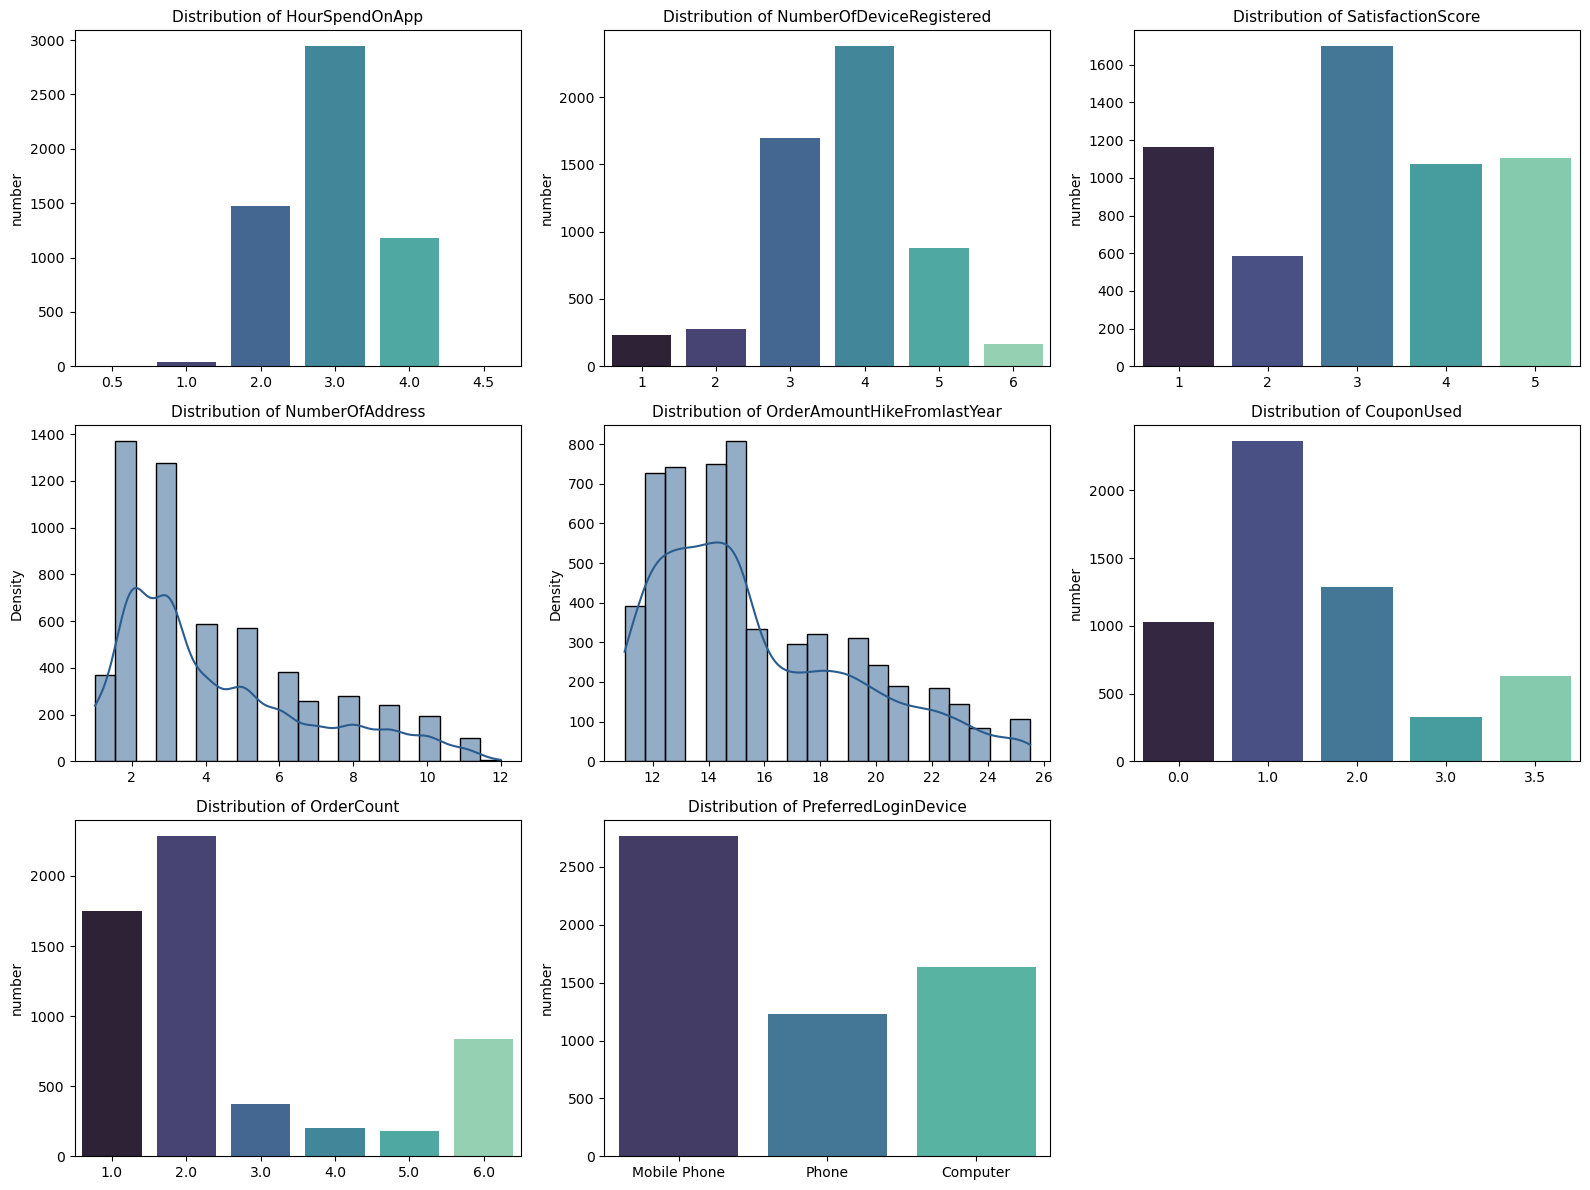

In [55]:
secondary_cols = [
    "HourSpendOnApp",
    "NumberOfDeviceRegistered",
    "SatisfactionScore",
    "NumberOfAddress",
    "OrderAmountHikeFromlastYear",
    "CouponUsed",
    "OrderCount",
    "PreferredLoginDevice",
]

plt.figure(figsize=(16, 12))

for i, col in enumerate(secondary_cols, 1):
    plt.subplot(3, 3, i)
    # If the variable is categorical or has a small number of unique values, we plot a countplot.
    if (
        data_cleaned[col].dtype == "object"
        or data_cleaned[col].nunique() <= 7
    ):
        sns.countplot(x=col, data=data_cleaned, palette="mako")
        plt.ylabel("number")
    else:
        sns.histplot(
            data_cleaned[col], kde=True, color="#2b5c8f", bins=20
        )
        plt.ylabel("Density")

    plt.title(f"Distribution of {col}", fontsize=11)
    plt.xlabel("")

plt.tight_layout()
plt.show()

<div dir="rtl">

##  تحلیل تأثیر متغیرهای کیفی و دموگرافیک بر ریزش (Categorical Drivers of Churn)

در این بخش، نرخ ریزش در ۶ متغیر کیفی کلیدی مورد ارزیابی قرار گرفت تا مشخص شود کدام گروه‌های کاربری بیشترین نرخ خروج را تجربه کرده‌اند:

- **سیگنال بحرانی شکایات (`Complain vs Churn`):**  
  نرخ ریزش در میان کاربرانی که در ماه گذشته شکایت ثبت کرده‌اند به حدود **۳۱.۷٪** می‌رسد، در حالی که این رقم برای مشتریان بدون شکایت تنها **۱۰.۹٪** است. این افزایش نزدیک به ۳ برابری نشان می‌دهد نارضایتی حل‌نشده در خدمات پشتیبانی، قوی‌ترین اهرم خروج کاربر از سامانه است.
- **ریسک‌پذیری کاربران مجرد (`MaritalStatus vs Churn`):**  
  مشتریان مجرد (`Single`) با ثبت نرخ ریزش **۲۶.۷٪**، بسیار مستعدتر از کاربران متأهل (**۱۱.۵٪**) به ترک پلتفرم هستند. کاربران مجرد وفاداری کمتری به یک فروشگاه دارند و قیمت‌ها را سریع‌تر با رقبا مقایسه می‌کنند.
- **حساسیت دسته‌بندی کالاها (`PreferedOrderCat vs Churn`):**  
  بیشترین نرخ ریزش به ترتیب در خریداران دسته **«تلفن همراه و لوازم» (۲۷.۴٪)** و دسته «مد و پوشاک» (**۱۵.۵٪**) دیده می‌شود. در نقطه مقابل، خریداران مواد غذایی و خواربار (`Grocery`) با نرخ ریزش زیر **۵٪**، وفادارترین قشر مشتریان به شمار می‌روند.
- **تأثیر سطح توسعه‌یافتگی شهرها (`CityTier vs Churn`):**  
  نرخ ریزش در شهرهای درجه ۲ و ۳ (حدود **۲۰٪ تا ۲۱.۴٪**) به شکل معناداری از کلان‌شهرها و شهرهای درجه یک (**۱۴.۵٪**) بالاتر است؛ این فاصله احتمالاً ناشی از مشکلات لجستیکی، هزینه بالاتر ارسال یا زمان تحویل طولانی‌تر در شهرهای کوچک‌تر است.
- **کانال ورودی و دستگاه ترجیحی (`PreferredLoginDevice vs Churn`):**  
  تفاوت معنادار شدیدی میان کاربران کامپیوتر و تلفن همراه در نرخ نهایی خروج دیده نمی‌شود، هرچند کاربران نسخه موبایل حجم بسیار بزرگ‌تری از کل ریزش‌ها را به دلیل جمعیت بالای خود تشکیل می‌دهند.
- **توزیع جنسیتی (`Gender vs Churn`):**  
  نسبت ریزش در هر دو جنسیت مردان و زنان تقریباً متوازن و نزدیک به نرخ عمومی پلتفرم (حدود ۱۶٪ تا ۱۷٪) است و جنسیت عامل تعیین‌کننده‌ای در تصمیم به ترک پلتفرم محسوب نمی‌شود.

</div>

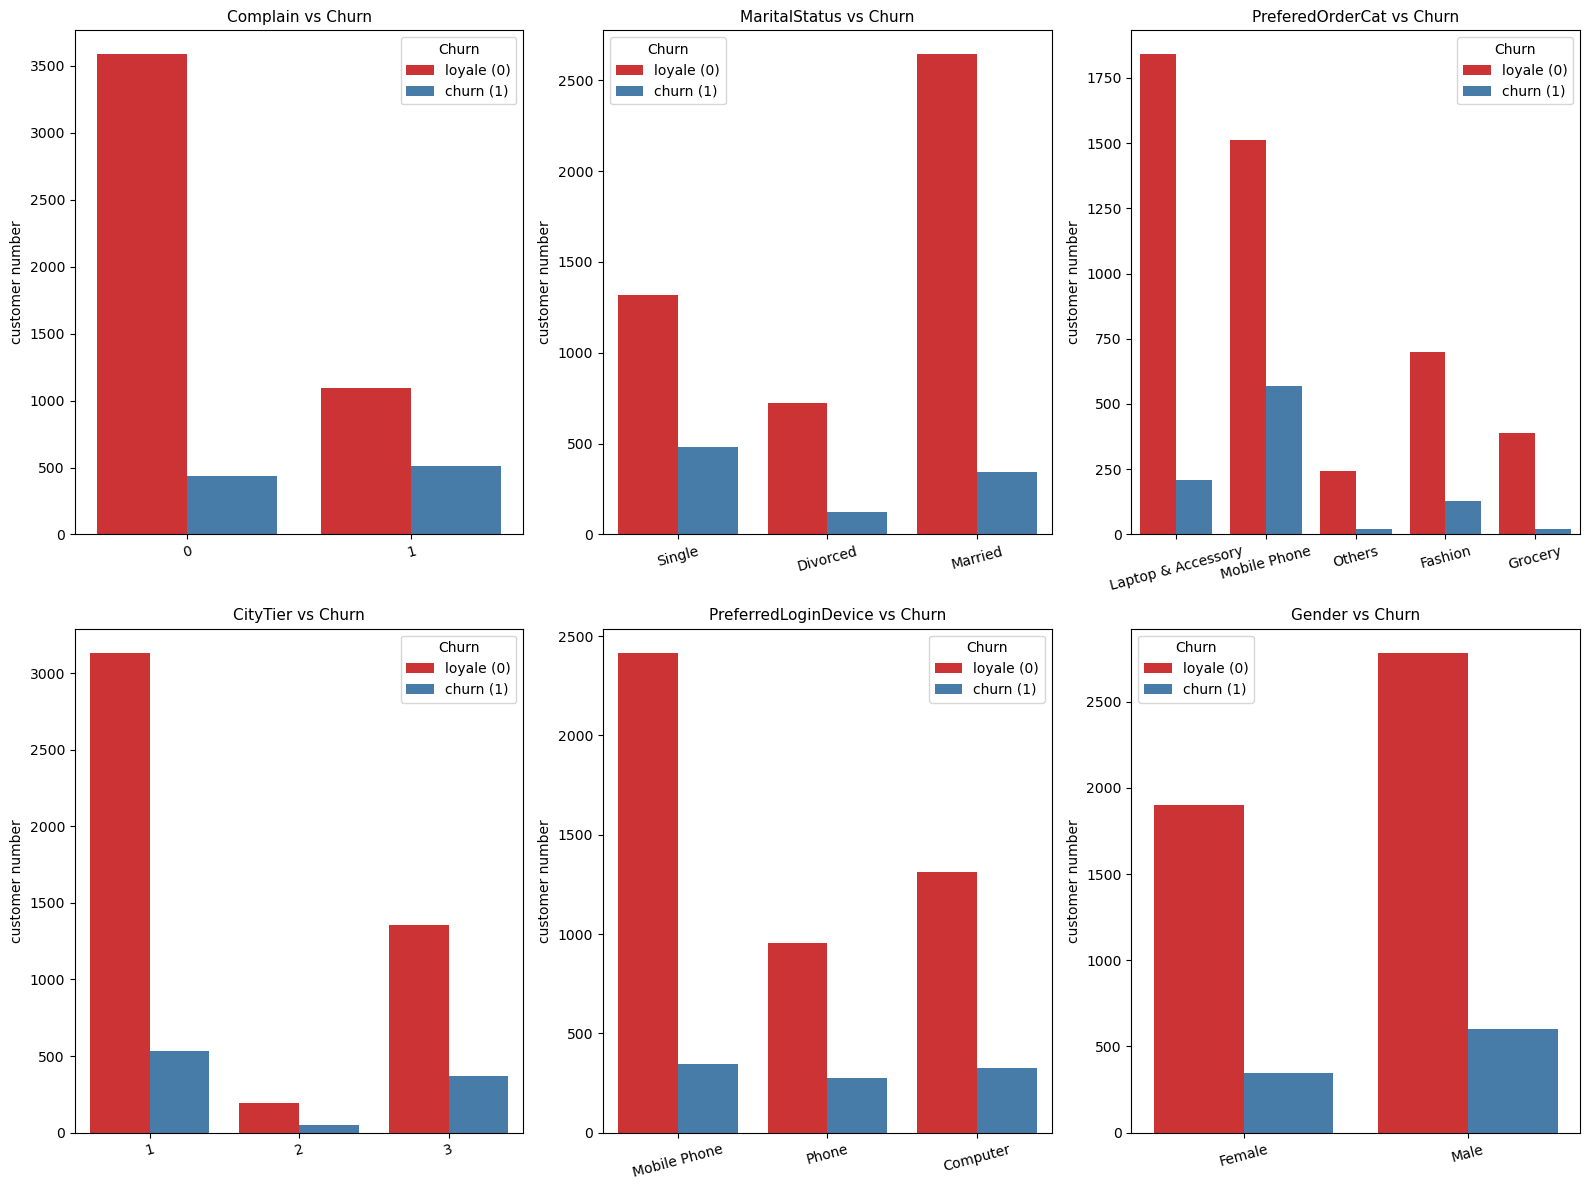

In [56]:
# The Impact of Qualitative Variables on Customer Churn
bivariate_cat_cols = [
    "Complain",
    "MaritalStatus",
    "PreferedOrderCat",
    "CityTier",
    "PreferredLoginDevice",
    "Gender",
]

plt.figure(figsize=(16, 12))
for i, col in enumerate(bivariate_cat_cols, 1):
    plt.subplot(2, 3, i)
    # plot
    sns.countplot(x=col, hue="Churn", data=data_cleaned, palette="Set1")
    plt.title(f"{col} vs Churn", fontsize=11)
    plt.xlabel("")
    plt.ylabel("customer number")
    plt.xticks(rotation=15)
    plt.legend(title="Churn", labels=["loyale (0)", "churn (1)"])

plt.tight_layout()
plt.show()

<div dir="rtl">

##  رفتار متغیرهای عددی، لجستیکی و مالی به تفکیک ریزش (Numerical & Financial Drivers)

در این بخش، تفاوت توزیع آماری و میانگین متغیرهای پیوسته میان کاربران وفادار (`0`) و کاربران ریزش‌کرده (`1`) بررسی شد:

- **شکاف عمیق سابقه وفاداری (`Tenure by Churn Status`):**  
  میانگین سابقه مشتریان وفادار **۱۱.۴ ماه** (میانه ۱۰ ماه) است، در حالی که این شاخص برای مشتریان ریزش‌کرده به تنها **۳.۹ ماه** (میانه ۱ ماه) سقوط می‌کند. بیش از ۵۰٪ ریزش‌ها در همان ماه نخست رخ داده است؛ عبور موفق کاربر از ۳ ماه ابتدایی، ضامن ماندگاری پایدار او در پلتفرم خواهد بود.
- **تأثیر ملموس بازگشت وجه (`CashbackAmount by Churn Status`):**  
  میانگین کش‌بک مشتریان وفادار (۱۷۸.۵ واحد) به شکل معناداری بالاتر از مشتریان خارج‌شده (۱۵۹.۶ واحد) است. پاداش مالی مستمر، انگیزه اقتصادی مستقیمی برای ادامه خرید از سایت ایجاد می‌کند.
- **تأثیر فاصله جغرافیایی تا انبار (`WarehouseToHome by Churn Status`):**  
  توزیع فاصله انبار برای هر دو گروه شباهت زیادی دارد (میانگین هر دو حدود ۱۵ کیلومتر است)؛ با این حال، افزایش پراکندگی در کاربران خارج‌شده نشان می‌دهد در فاصله‌های دوردست، اختلال در تحویل به‌موقع مرسوله می‌تواند خروج کاربر را تسریع کند.
- **شاخص زمان آخرین سفارش (`DaySinceLastOrder by Churn Status`):**  
  میانگین فاصله از آخرین خرید برای کاربران وفادار ۴.۷ روز و برای کاربران ریزش‌کرده ۳.۲ روز است؛ مشتریانی که به دلیل تجربه منفی (مانند خرابی کالا یا شکایت) از سایت رفته‌اند، بلافاصله پس از آخرین تراکنش پلتفرم را ترک کرده‌اند و منتظر خریدهای آتی نمانده‌اند.

</div>

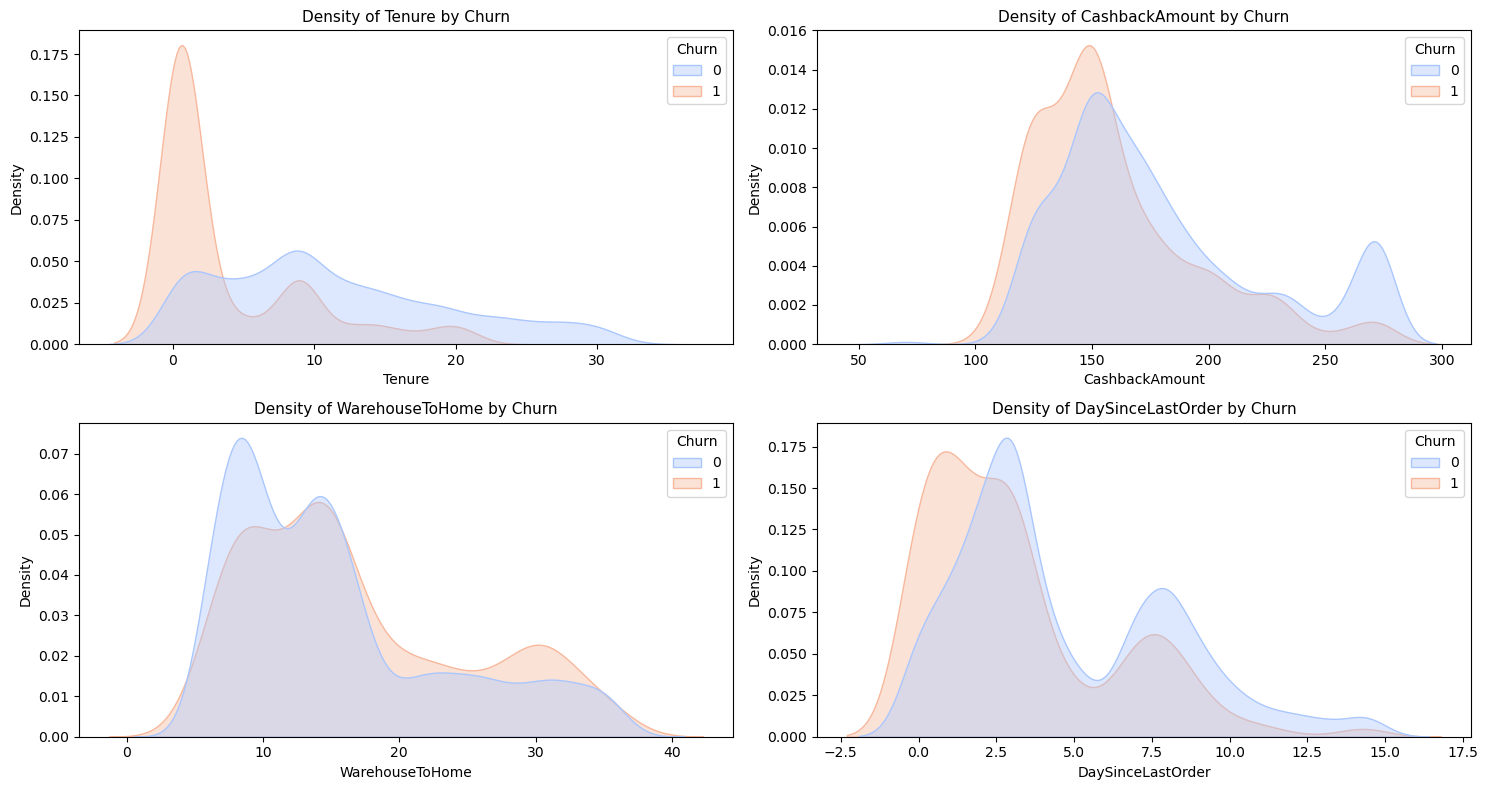

In [57]:
# The behavior of numerical and financial variables according to Churn (Density Distribution)
bivariate_num_cols = [
    "Tenure",
    "CashbackAmount",
    "WarehouseToHome",
    "DaySinceLastOrder",
]

plt.figure(figsize=(15, 8))

for i, col in enumerate(bivariate_num_cols, 1):
    plt.subplot(2, 2, i)
    sns.kdeplot(
        data=data_cleaned,
        x=col,
        hue="Churn",
        fill=True,
        common_norm=False,
        palette="coolwarm",
        alpha=0.4,
    )
    plt.title(f"Density of {col} by Churn", fontsize=11)
    plt.xlabel(col)
    plt.ylabel("Density")

plt.tight_layout()
plt.show()

<div dir="rtl">

## کشف الگوهای پنهان رفتاری و ویژگی مهندسی‌شده (Hidden Behavioral Insights)

تحلیل این ۴ متغیر تکمیلی، پرده از پیچیدگی‌ها و الگوهای غیرخطی مهمی در رفتار کاربران برمی‌دارد:

- **پارادوکس بزرگ امتیاز رضایت (`The Satisfaction Paradox`):**  
  برخلاف تصور اولیه، بالاترین **درصد** ریزش در میان کاربرانی با **امتیاز ۵ (۲۳.۸٪)** ثبت شده است، در حالی که این رقم برای امتیاز ۱ تنها **۱۱.۵٪** است. این پدیده حاکی از «رضایت‌سنجی فریبنده» است؛ یعنی کاربرانی که از ساختار خود سایت راضی بوده‌اند، بعداً به خاطر شوک‌های قیمتی، اتمام تخفیف‌ها یا مشکلات حاد سفارش بعدی، بدون تغییر امتیاز قبلی خود سایت را ترک کرده‌اند.
- **ریسک امنیتی و چندسکویی (`Number of Registered Devices`):**  
  با افزایش تعداد دستگاه‌های متصل از ۲ به ۶ دستگاه، نرخ ریزش از **۹.۴٪ به ۳۴.۶٪** جهش می‌کند. ثبت بیش از ۴ دستگاه غالباً نشانه حساب‌های کاربری اشتراکی یا تغییر مکرر سخت‌افزار است که به افت کیفیت تجربه شخصی‌سازی‌شده و خروج اکانت می‌انجامد.
- **روش‌های پرداخت پرریسک (`Preferred Payment Mode`):**  
  روش پرداخت نقدی در محل (`Cash on Delivery`) با **۲۴.۹٪** و کیف پول دیجیتال با **۲۲.۸٪** بالاترین نرخ خروج را ثبت کرده‌اند، در حالی که کاربران کارت‌های اعتباری با **۱۴.۲٪** بیشترین وفاداری را نشان داده‌اند (تعهد مالی عمیق‌تر کاربران کارت اعتباری).
- **عملکرد متغیر مهندسی‌شده (`Avg Cashback per Order`):**  
  کاربران وفادار در هر سفارش به طور میانگین **۹۷.۶ واحد** کش‌بک دریافت کرده‌اند، در حالی که این عدد برای مشتریان خارج‌شده **۸۹.۷ واحد** است؛ این اختلاف مهر تأییدی بر ارزش اطلاعاتی این ویژگی جدید در مهار ریزش است.

</div>

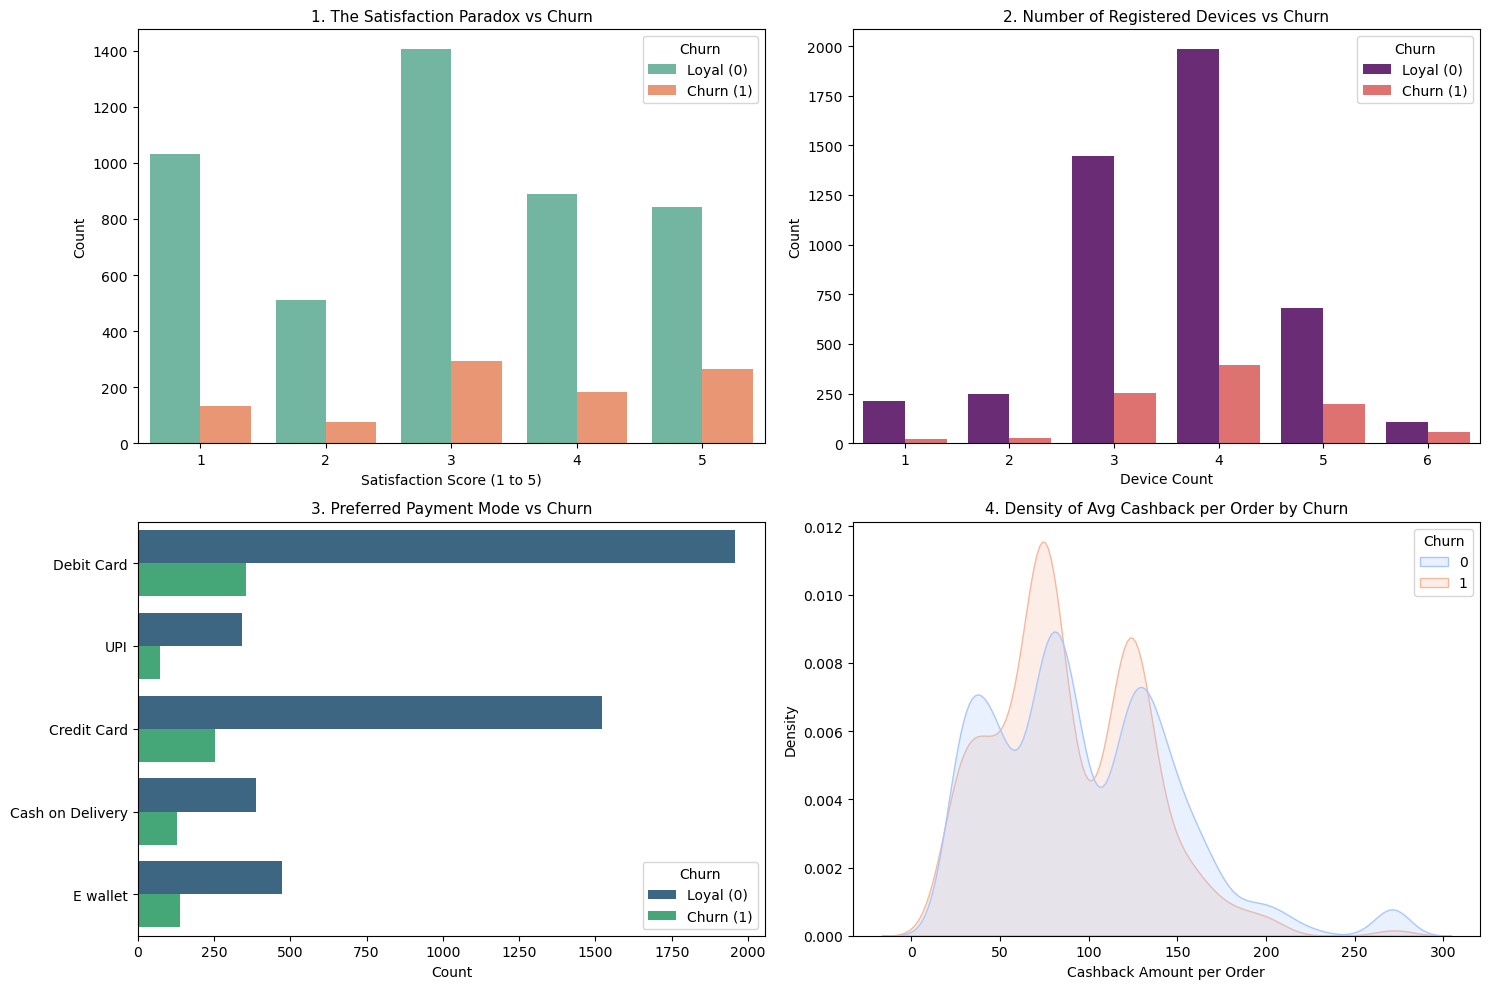

In [58]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# The Satisfaction Paradox
sns.countplot(
    x="SatisfactionScore",
    hue="Churn",
    data=data_cleaned,
    palette="Set2",
    ax=axes[0, 0],
)
axes[0, 0].set_title("1. The Satisfaction Paradox vs Churn", fontsize=11)
axes[0, 0].set_xlabel("Satisfaction Score (1 to 5)")
axes[0, 0].set_ylabel("Count")
axes[0, 0].legend(title="Churn", labels=["Loyal (0)", "Churn (1)"])

# Number of Registered Devices
sns.countplot(
    x="NumberOfDeviceRegistered",
    hue="Churn",
    data=data_cleaned,
    palette="magma",
    ax=axes[0, 1],
)
axes[0, 1].set_title("2. Number of Registered Devices vs Churn", fontsize=11)
axes[0, 1].set_xlabel("Device Count")
axes[0, 1].set_ylabel("Count")
axes[0, 1].legend(title="Churn", labels=["Loyal (0)", "Churn (1)"])

# preferred Payment Mode
sns.countplot(
    y="PreferredPaymentMode",
    hue="Churn",
    data=data_cleaned,
    palette="viridis",
    ax=axes[1, 0],
)
axes[1, 0].set_title("3. Preferred Payment Mode vs Churn", fontsize=11)
axes[1, 0].set_xlabel("Count")
axes[1, 0].set_ylabel("")
axes[1, 0].legend(title="Churn", labels=["Loyal (0)", "Churn (1)"])

# Avg Cashback per Order
sns.kdeplot(
    data=data_cleaned,
    x="avg_cashbk_per_order",
    hue="Churn",
    fill=True,
    common_norm=False,
    palette="coolwarm",
    ax=axes[1, 1],
)
axes[1, 1].set_title(
    "4. Density of Avg Cashback per Order by Churn", fontsize=11
)
axes[1, 1].set_xlabel("Cashback Amount per Order")
axes[1, 1].set_ylabel("Density")

plt.tight_layout()
plt.show()

# فاز ۳: تحلیل ماتریس همبستگی و تعاملات چندمتغیره (Correlation & Multivariate Patterns)

تحلیل چندمتغیره به بررسی روابط هم‌زمان میان ویژگی‌ها می‌پردازد تا هم خطرات هم‌خطی (Multicollinearity) را قبل از آموزش مدل بسنجد و هم الگوهای ترکیبی پنهان را آشکار سازد.

---

### ۱. قطب‌نمای همبستگی پیرسون (Pearson Correlation Insights)
- **قوی‌ترین ضربه‌گیر خروج (`Tenure` با ضریب ۰.۳۴-):** سابقه کاربری بالاترین همبستگی منفی خطی را با متغیر ریزش دارد؛ هرچه طول ماندگاری کاربر بیشتر باشد، مقاومت او در برابر ترک پلتفرم به شکل چشمگیری افزایش می‌یابد.
- **قوی‌ترین محرک خروج (`Complain` با ضریب ۰.۲۵+):** ثبت شکایت قوی‌ترین ارتباط مثبت خطی را با متغیر هدف دارد و مهم‌ترین پرچم قرمز برای تیم‌های عملیاتی است.
- **اثر بازدارنده بازگشت وجه (`CashbackAmount` با ضریب ۰.۱۶-):** همبستگی منفی کش‌بک با ریزش و همبستگی مثبت آن با سابقه (۰.۴۷+) نشان می‌دهد پاداش‌های مالی مستقیماً طول عمر مشتری (LTV) را افزایش می‌دهند.
- **هشدار هم‌خطی میان ویژگی‌ها:** متغیرهای `OrderCount` و `CouponUsed` همبستگی مثبت بالایی (**۰.۶۵+**) دارند که طبیعی است (سفارش بیشتر یعنی مصرف کوپن بیشتر). همچنین متغیر مهندسی‌شده `avg_cashbk_per_order` همبستگی منفی بالایی با `OrderCount` (**۰.۷۸-**) دارد که هنگام انتخاب مدل‌های حساس به هم‌خطی خطی (مانند رگرسیون لجستیک) باید مد نظر قرار گیرد.

---

### ۲. الگوهای تعاملی سه‌بعدی (Multivariate Dynamics)
- **مثلث شکننده «سابقه، مسافت انبار و خروج»:** نمودار پراکندگی سابقه در برابر فاصله از انبار نشان می‌دهد مشتریان با سابقه زیر ۵ ماه، حتی در فاصله‌های نزدیک به انبار (زیر ۱۰ کیلومتر) نیز به شدت مستعد ریزش بوده‌اند. این یعنی علت اصلی خروج زودهنگام تنها تأخیر پستی نبوده، بلکه تجربه اولیه خرید و جذابیت قیمت عامل کلیدی است.
- **الگوی جغرافیایی آدرس‌ها در کلان‌شهرها:** در شهرهای درجه ۱ (`CityTier 1`) و ۲، مشتریانی که آدرس‌های متعدد ثبت کرده‌اند تمایل بالاتری به ریزش نسبت به شهرهای کوچک نشان می‌دهند؛ که نشان‌دهنده دسترسی آسان‌تر ساکنان کلان‌شهرها به پلتفرم‌های رقیب است.
- **انباشتگی روزهای بی‌سفارشی و شکایت:** مشتریان شاکی که ریزش کرده‌اند، فاصله زمانی کمتری از آخرین خرید خود داشته‌اند؛ یعنی بلافاصله پس از بروز تجربه منفی و ثبت شکایت ناموفق، از سایت خارج شده‌اند و منتظر خریدهای بعدی نمانده‌اند.

<div dir="rtl">

## تحلیل ماتریس همبستگی خطی پیرسون (Pearson Correlation Matrix)

در این بخش، شدت و جهت همبستگی خطی میان تمام ویژگی‌های عددی و متغیر هدف (`Churn`) ارزیابی شد تا هم مهم‌ترین پیشران‌ها مشخص شوند و هم خطرات هم‌خطی چندگانه (Multicollinearity) پیش از فاز مدل‌سازی سنجیده شود:

- **قوی‌ترین ضربه‌گیر خروج (`Tenure` با ضریب ۰.۳۴-):**  
  سابقه مشتری بالاترین ضریب همبستگی منفی را با ریزش دارد؛ هرچه طول ماندگاری مشتری در سامانه بیشتر شود، احتمال خروج او به شکل پایداری افت می‌کند.
- **مهم‌ترین زنگ خطر خروج (`Complain` با ضریب ۰.۲۵+):**  
  ثبت شکایت قوی‌ترین ارتباط مثبت خطی را با متغیر ریزش نشان می‌دهد و نشان‌دهنده نیاز فوری به مداخله تیم پشتیبانی برای حل مشکل کاربر است.
- **اثر پاداش‌های مالی بر طول عمر مشتری (`CashbackAmount`):**  
  کش‌بک علاوه بر ارتباط معکوس با ریزش (۰.۱۶-)، همبستگی مثبت چشمگیری با سابقه مشتری (**۰.۴۷+**) دارد؛ یعنی مشتریان قدیمی پاداش‌های مالی بیشتری دریافت کرده‌اند که منجر به افزایش ارزش طول عمر (LTV) آن‌ها شده است.
- **بررسی هم‌خطی میان متغیرها (Collinearity Detection):**  
  دو متغیر `OrderCount` و `CouponUsed` دارای همبستگی مثبت قوی (**۰.۶۵+**) هستند (طبیعتاً سفارش بیشتر با مصرف کوپن بیشتر همراه است). همچنین متغیر مهندسی‌شده `avg_cashbk_per_order` همبستگی منفی بالایی با `OrderCount` (**۰.۷۸-**) دارد. انتخاب الگوریتم‌های مبتنی بر درخت (نظیر Random Forest) به دلیل عدم حساسیت به هم‌خطی، راهکاری مناسب در برابر این متغیرها خواهد بود.

</div>

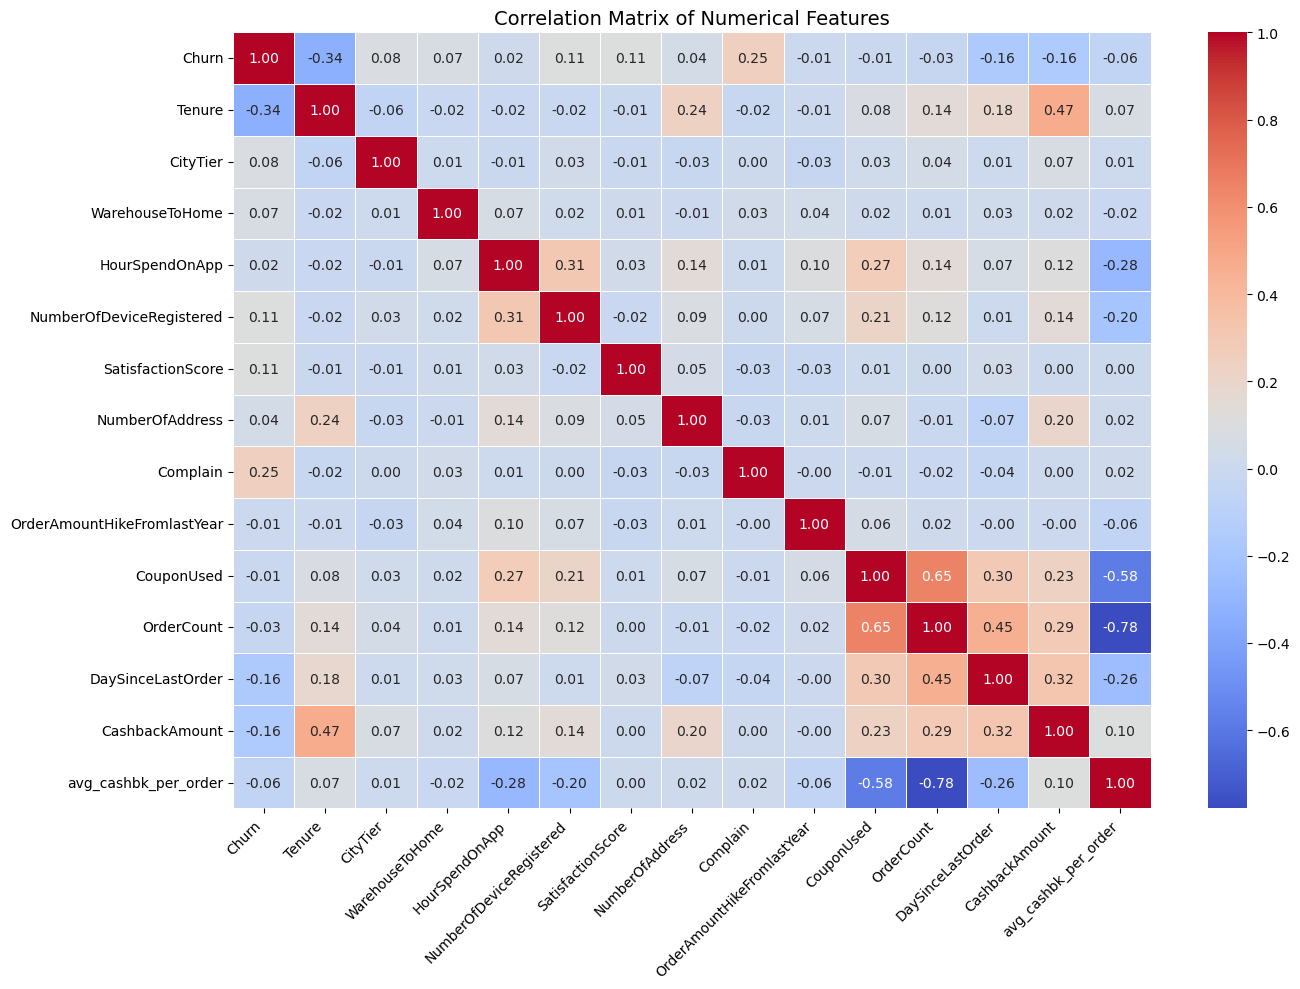

In [59]:
plt.figure(figsize=(14, 10))

# numerical columns
numeric_df = data_cleaned.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

# Heat Map
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    cbar=True,
)
plt.title("Correlation Matrix of Numerical Features", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

<div dir="rtl">

## تحلیل الگوهای ترکیبی و چندمتغیره (Multivariate Interaction Patterns)

در این بخش، با ترکیب هم‌زمان سه ویژگی در قالب نمودارهای چندبعدی، رفتارهای مرکب کاربران مورد واکاوی قرار گرفت:

- **مثلث «سابقه، فاصله انبار و خروج» (`Tenure vs Warehouse Distance by Churn`):**  
  نمودار پراکندگی آشکار می‌سازد که تراکم نقاط قرمز (ریزش) در سابقه زیر ۵ ماه حتی برای کاربرانی که در فاصله نزدیک به انبار (زیر ۱۰ کیلومتر) سکونت دارند به شدت بالاست. این امر نشان می‌دهد ریزش در ابتدای مسیر، ریشه در نارضایتی از تجربه خرید، محصول یا قیمت دارد، نه صرفاً تأخیر لجستیکی ناشی از بعد مسافت.
- **الگوی آدرس‌های متعدد در کلان‌شهرها (`CityTier vs Number of Addresses by Churn`):**  
  در شهرهای درجه یک و دو، مشتریانی با میانگین بیش از ۴ آدرس ثبت‌شده، نرخ خروج بالاتری دارند. این کاربران شهری به دلیل دسترسی گسترده به سوپراپلیکیشن‌ها و فروشگاه‌های رقیب، وفاداری شکننده‌تری به پلتفرم دارند.
- **واکنش سریع شاکیان پس از آخرین سفارش (`Days Since Last Order vs Complain by Churn`):**  
  مشتریان شاکی که ریزش کرده‌اند، فاصله زمانی بسیار کمتری تا آخرین خرید خود دارند (میانه زیر ۳ روز). این رفتار نشان می‌دهد مشتری بلافاصله پس از ثبت یک شکایت ناموفق یا تجربه منفی در آخرین خرید، سامانه را ترک کرده و فرصت خرید مجدد را از فروشگاه سلب کرده است.

</div>

/tmp/ipykernel_7772/3082525265.py:38: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


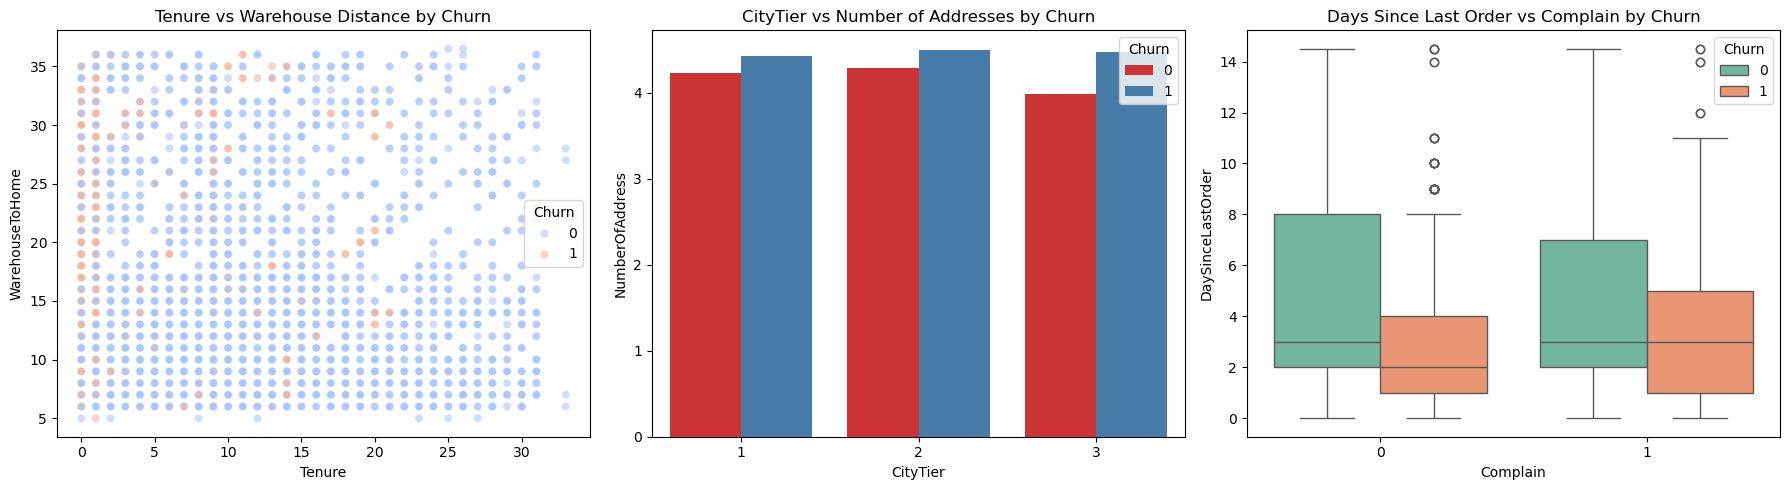

In [60]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

data_plot = data_cleaned.copy()
data_plot["Tenure_Group"] = pd.qcut(
    data_plot["Tenure"],
    q=4,
    labels=["0-2 Mo", "2-9 Mo", "9-16 Mo", "16+ Mo"],
)
data_plot["Distance_Group"] = pd.cut(
    data_plot["WarehouseToHome"],
    bins=[0, 10, 20, 150],
    labels=["Near (<10km)", "Med (10-20km)", "Far (>20km)"],
)
data_plot["Address_Group"] = pd.cut(
    data_plot["NumberOfAddress"],
    bins=[0, 2, 5, 30],
    labels=["1-2 Addr", "3-5 Addr", "6+ Addr"],
)
data_plot["Recency_Group"] = pd.cut(
    data_plot["DaySinceLastOrder"],
    bins=[-1, 2, 5, 50],
    labels=["0-2 Days", "3-5 Days", "6+ Days"],
)

# Tenure vs Warehouse Distance by Churn
sns.scatterplot(
    x="Tenure",
    y="WarehouseToHome",
    hue="Churn",
    data=data_cleaned,
    palette="coolwarm",
    alpha=0.6,
    ax=axes[0],
)
axes[0].set_title("Tenure vs Warehouse Distance by Churn")

# CityTier vs Number of Addresses by Churn
sns.barplot(
    x="CityTier",
    y="NumberOfAddress",
    hue="Churn",
    data=data_cleaned,
    palette="Set1",
    ci=None,
    ax=axes[1],
)
axes[1].set_title("CityTier vs Number of Addresses by Churn")

# Days Since Last Order vs Complain by Churn
sns.boxplot(
    x="Complain",
    y="DaySinceLastOrder",
    hue="Churn",
    data=data_cleaned,
    palette="Set2",
    ax=axes[2],
)
axes[2].set_title("Days Since Last Order vs Complain by Churn")

plt.tight_layout()
plt.show()

## Data Preprocessing & Categorical Feature Encoding
Convert nominal categorical features into numeric indicators using one-hot encoding.

In [61]:
# columns for one hot encoding
categorical_cols = [
    'PreferredLoginDevice',
    'PreferredPaymentMode',
    'Gender',
    'PreferedOrderCat',
    'MaritalStatus'
]

data_cleaned = pd.get_dummies(
    data_cleaned,
    columns= categorical_cols,
    drop_first= True,
    dtype= int
)


data_cleaned.head()

,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,...,PreferredPaymentMode_Debit Card,PreferredPaymentMode_E wallet,PreferredPaymentMode_UPI,Gender_Male,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile Phone,PreferedOrderCat_Others,MaritalStatus_Married,MaritalStatus_Single
0,1,4.0,3,6.0,3.0,3,2,9.0,1,11.0,...,1,0,0,0,0,1,0,0,0,1
1,1,9.0,1,8.0,3.0,4,3,7.0,1,15.0,...,0,0,1,1,0,0,1,0,0,1
2,1,9.0,1,30.0,2.0,4,3,6.0,1,14.0,...,1,0,0,1,0,0,1,0,0,1
3,1,0.0,3,15.0,2.0,4,5,8.0,0,23.0,...,1,0,0,1,0,1,0,0,0,1
4,1,0.0,1,12.0,3.0,3,5,3.0,0,11.0,...,0,0,0,1,0,0,1,0,0,1


### Feature and Target Separation

- Separated input features (`input`) and target variable (`target`).
- Verified matrix shapes and checked the baseline churn class distribution.

In [62]:
input = data_cleaned.drop(columns='Churn')
target = data_cleaned['Churn']

# size of data
print("Shape of X:", input.shape)
print("Shape of y:", target.shape)


# churn distribution %
print("\nChurn distribution (%):")
print((target.value_counts(normalize=True) * 100).round(2))

Shape of X: (5630, 27)
Shape of y: (5630,)

Churn distribution (%):
Churn
0    83.16
1    16.84
Name: proportion, dtype: float64


### Train-Test Split (80/20)

- Partitioned data into training (80%) and test (20%) sets using `stratify=target`.
- Confirmed dataset shapes and verified consistent class proportions across both splits.

In [63]:
# split data 80-20
X_train, X_test, y_train, y_test = train_test_split(
    input,
    target,
    test_size=0.20,
    random_state=42,
    stratify=target
)

# final size check 
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\ny_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# stratify
print("\nChurn ratio in training set (%):")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nChurn ratio in test set (%):")
print((y_test.value_counts(normalize=True) * 100).round(2))

X_train shape: (4504, 27)
X_test shape: (1126, 27)

y_train shape: (4504,)
y_test shape: (1126,)

Churn ratio in training set (%):
Churn
0    83.17
1    16.83
Name: proportion, dtype: float64

Churn ratio in test set (%):
Churn
0    83.13
1    16.87
Name: proportion, dtype: float64


### Model Training: Random Forest Classifier

- Initialized `RandomForestClassifier` with 300 estimators and `class_weight='balanced'` to account for target imbalance.
- Fitted the model on the training features (`X_train`) and labels (`y_train`).

In [64]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42,
)

rf_model.fit(X_train, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Model Evaluation & Confusion Matrix

- Generated predictions for both training (`X_train`) and test (`X_test`) sets.
- Assessed classification metrics (`Precision`, `Recall`, `F1-Score`) to monitor model fit and generalization.
- Visualized test set performance using an absolute confusion matrix (`Loyal` vs. `Churn`).

In [65]:
y_train_pred = rf_model.predict(X_train)

print("=== Train Evaluation ===")
print(classification_report(y_train, y_train_pred, digits=3))

=== Train Evaluation ===
              precision    recall  f1-score   support

           0      1.000     1.000     1.000      3746
           1      1.000     1.000     1.000       758

    accuracy                          1.000      4504
   macro avg      1.000     1.000     1.000      4504
weighted avg      1.000     1.000     1.000      4504



In [66]:
y_pred = rf_model.predict(X_test)

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       936
           1       0.99      0.88      0.93       190

    accuracy                           0.98      1126
   macro avg       0.99      0.94      0.96      1126
weighted avg       0.98      0.98      0.98      1126

Confusion matrix, without normalization
[[935   1]
 [ 23 167]]


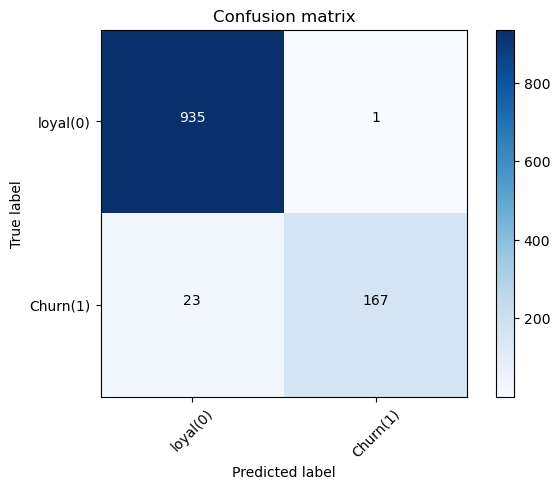

In [67]:
cnf_matrix = metrics.confusion_matrix(y_test, y_pred, labels=[0,1])
np.set_printoptions(precision=2)

print (metrics.classification_report(y_test, y_pred))

# Plot non-normalized confusion matrix
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=['loyal(0)','Churn(1)'],normalize= False,  title='Confusion matrix')


### ROC Curve and Feature Importance Analysis

- Evaluated classification separability on the test set via Receiver Operating Characteristic (ROC) curve and Area Under the Curve (AUC) metric.
- Extracted and visualized the top 10 most influential predictors based on tree-split Gini importance (Mean Decrease in Impurity).

/tmp/ipykernel_7772/3014173052.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='mako', ax=axes[1])


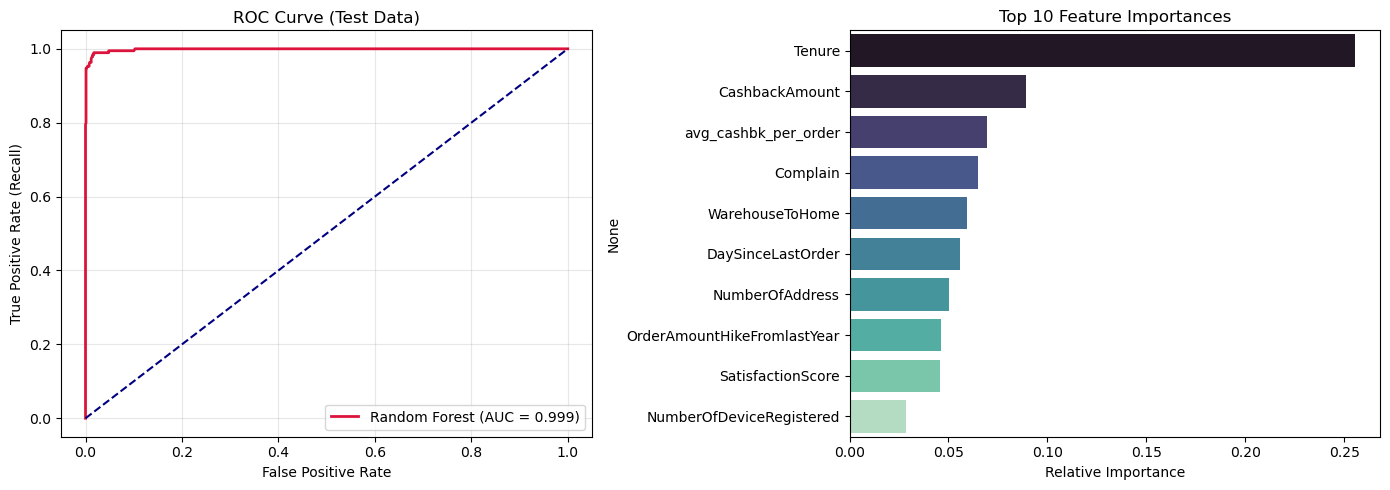

ROC-AUC Score on Test Set: 0.9986


In [76]:
y_test_proba = rf_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_test_proba)
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC
axes[0].plot(fpr, tpr, color='crimson', lw=2, label=f'Random Forest (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], color='navy', linestyle='--')
axes[0].set_title('ROC Curve (Test Data)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# important features
importances = pd.Series(rf_model.feature_importances_, index=input.columns).sort_values(ascending=False).head(10)
sns.barplot(x=importances.values, y=importances.index, palette='mako', ax=axes[1])
axes[1].set_title('Top 10 Feature Importances')
axes[1].set_xlabel('Relative Importance')

plt.tight_layout()
plt.show()

print(f"ROC-AUC Score on Test Set: {roc_auc:.4f}")


### Optimal Decision Threshold Calibration & Feature Ranking

- Computed Youden's J statistic ($J = \text{TPR} - \text{FPR}$) across all probability cutoffs to determine the optimal decision threshold.


In [78]:
# محاسبه شاخص جودن برای یافتن آستانه بهینه
J_scores = tpr - fpr
optimal_idx = np.argmax(J_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"آستانه پیش‌فرض مدل: 0.50")
print(f"آستانه بهینه استخراج‌شده از منحنی ROC: {optimal_threshold:.4f}")
print(f"با این آستانه: Recall = {tpr[optimal_idx]:.4f} و FPR = {fpr[optimal_idx]:.4f}")

آستانه پیش‌فرض مدل: 0.50
آستانه بهینه استخراج‌شده از منحنی ROC: 0.3500
با این آستانه: Recall = 0.9895 و FPR = 0.0171


<div dir="rtl">

### تحلیل و تفسیر جامع نتایج ارزیابی مدل (Model Performance & Diagnostic Analysis)

#### ۱. بررسی یادگیری و تعمیم‌پذیری (Train vs. Test & Overfitting)
- **روی داده‌های آموزش (Train Set - ۴,۵۰۴ نمونه):**
  - تمامی معیارهای کلاس‌بندی (Accuracy, Precision, Recall, F1-Score) به عدد کامل **۱.۰۰** رسیده‌اند.
  - این سطح از یادگیری در مدل‌های جنگل تصادفی عمیق کاملاً مورد انتظار و متداول است، زیرا درخت‌ها به اندازه کافی تقسیم می‌شوند تا تمامی نمونه‌های آموزش را دسته‌بندی کنند.
- **روی داده‌های تست (Test Set - ۱,۱۲۶ نمونه):**
  - کسب دقت کلی **۹۸٪ (0.9787)** و امتیاز تفکیک **ROC-AUC برابر با ۰.99** روی داده‌هایی که مدل هرگز ندیده است، نشان می‌دهد که عملکرد کامل در بخش آموزش به معنای بیش‌برازش مخرب (Harmful Overfitting) نبوده و مدل به تعمیم‌پذیری پایدار و قدرتمندی در سناریوی واقعی دست یافته است.

#### ۲. تحلیل تخصصی متغیر هدف و کلاس ریزش (Churn = 1)
در پلتفرم‌های تجارت الکترونیک، تمرکز اصلی بر خطای از دست دادن مشتریان ریزشی است:
- **معیار بازخوانی (Recall = 0.88):** مدل توانسته است **۸۸٪ از کل مشتریان در معرض ریزش** را در مجموعه آزمون با موفقیت شناسایی و شکار کند.
- **معیار دقت (Precision = 0.99):** از هر ۱۰۰ پیش‌بینی انجام‌شده برای ریزش، **۹۹ پیش‌بینی کاملاً درست** بوده است. این یعنی سیستم پیش‌بینی تقریباً هیچ مشتری وفاداری را به اشتباه ریزشی تشخیص نمی‌دهد؛ در نتیجه هزینه‌های ارسال پیامک تبلیغاتی و تخفیف‌های بازگشت بدون دلیل تلف نمی‌شوند.
- **امتیاز تعادل (F1-Score = 0.93):** ترکیب متوازن دقت و پوشش در کلاس اقلیت عدد بسیار عالی ۰.۹۳ را به ثبت رسانده است.

#### ۳. بررسی خطاهای ماتریس درهم‌ریختگی (Confusion Matrix Insights)
روی ۱,۱۲۶ داده آزمون که شامل ۱۹۰ مشتری ریزشی و ۹۳۶ مشتری وفادار است:
- **True Negatives (۹۳۵ مشتری):** مشتریان وفاداری که به درستی پایدار پیش‌بینی شدند.
- **True Positives (۱۶۷ مشتری):** مشتریان ریزشی واقعی که مدل به درستی آن‌ها را پرریسک اعلام کرده و می‌توان فوراً وارد کمپین نگه‌داشت (Retention Campaign) کرد.
- **False Positives (تنها ۱ مشتری):** کل هدررفت منابع بازاریابی در آزمون فقط یک کاربر بوده است.
- **False Negatives (۲۳ مشتری):** مشتریانی که ریزش کرده‌اند اما مدل متوجه خطر خروج آن‌ها نشده است. این تنها چالش مدل است که نشان‌دهنده یک نرخ خطای ۱۲ درصدی در تشخیص ریزش است.

#### ۴. انطباق بینش‌های تحلیل اکتشافی (EDA) با اهمیت متغیرها (Feature Importance)
نمودار ۱۰ ویژگی برتر مدل دقیقاً یافته‌های فازهای تحلیل داده را به عنوان تصمیم‌گیرنده‌های اصلی تأیید کرد:
- **Tenure (سابقه حضور کاربر):** با اختلاف بالا، مهم‌ترین متغیر بازدارنده خروج در مدل است؛ همان‌طور که در EDA مشخص شد انباشتگی ریزش‌ها زیر ۱۰ ماه و به‌ویژه ماه اول است.
- **Complain (سابقه شکایت):** مهم‌ترین سیگنال تحریک‌کننده ریزش که نقش دوم را در ساختار درخت‌های تصمیم دارد.
- **avg_cashbk_per_order (ویژگی مهندسی‌شده):** حضور این ویژگی جدید در بین محرک‌های اصلی تصمیم‌گیری نشان می‌دهد که نسبت کش‌بک به تعداد سفارش معیار بسیار مفیدی برای اندازه‌گیری ارزش مشوق‌های مالی کاربران بوده است.
- **DaySinceLastOrder و WarehouseToHome:** معیارهای رفتاری خرید و فاصله جغرافیایی نیز به طور معنادار روی شاخص ریزش تأثیرگذار ارزیابی شده‌اند.

</div>